# Geospatial Data

In [9]:
!pip cache purge --quiet

In [10]:
!pip install geopandas==1.1.1 \
             matplotlib==3.10.3 --quiet

In [11]:
import pandas as pd
import geopandas as gpd

from shapely import wkt

In [12]:
# If you've forked this repo, change OWNER to your GitHub username.
# REPO and BRANCH will normally stay the same unless you renamed them.
OWNER = "singlestore-cookbook"
REPO = "singlestore-cookbook.github.io"
BRANCH = "refs/heads/main"

BASE_URL = f"https://raw.githubusercontent.com/{OWNER}/{REPO}/{BRANCH}/code/part-multi-model/geospatial-data/datasets"

In [13]:
boroughs_csv_url = f"{BASE_URL}/London_Borough_Excluding_MHW.csv"

boroughs_df = pd.read_csv(boroughs_csv_url)

In [14]:
boroughs_df["geometry"] = boroughs_df["WKT"].apply(wkt.loads)
boroughs_df = boroughs_df.rename(columns = {"NAME": "name", "HECTARES": "hectares"})
boroughs_df = boroughs_df.drop(
    columns = ["WKT", "GSS_CODE", "NONLD_AREA", "ONS_INNER", "SUB_2009", "SUB_2006"]
)

In [15]:
# Create GeoDataFrame and set CRS
boroughs_geo_df = gpd.GeoDataFrame(boroughs_df, geometry = "geometry")
boroughs_geo_df = boroughs_geo_df.set_crs(epsg = 4326, allow_override = True)

INFO:matplotlib.font_manager:generated new fontManager


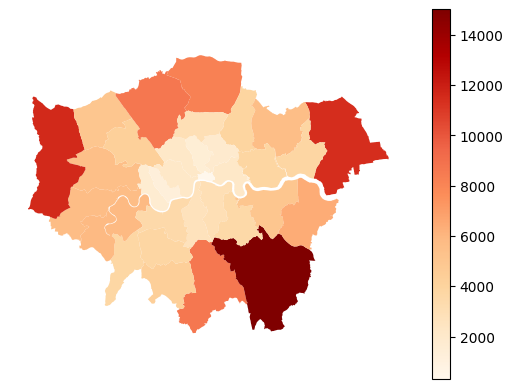

In [16]:
# Plot the map
map = boroughs_geo_df.plot(column = "hectares", cmap = "OrRd", legend = True)
map.set_axis_off()

"Contains National Statistics data © Crown copyright and database right [2015]" and "Contains Ordnance Survey data © Crown copyright and database right [2015]"

In [17]:
# Reproject to a projected CRS for accurate centroid calculation
boroughs_proj = boroughs_geo_df.to_crs(27700)

# Calculate centroids
boroughs_proj["centroid"] = boroughs_proj.geometry.centroid

# Transform centroids back to WGS 84
boroughs_geo_df["centroid"] = boroughs_proj["centroid"].to_crs(4326)

In [18]:
# Keep the original geometries and centroids but also add WKT versions
boroughs_geo_df["geometry_wkt"] = boroughs_geo_df["geometry"].apply(wkt.dumps)
boroughs_geo_df["centroid_wkt"] = boroughs_geo_df["centroid"].apply(wkt.dumps)

In [19]:
# Drop geometries and centroids
boroughs_geo_df = boroughs_geo_df.drop(columns = ["geometry", "centroid"])
boroughs_geo_df = boroughs_geo_df.rename(columns = {"geometry_wkt": "geometry", "centroid_wkt": "centroid"})

<div class="alert alert-block alert-warning">
    <b class="fa fa-solid fa-exclamation-circle"></b>
    <div>
        <p><b>Action Required</b></p>
        <p>Select the database from the drop-down menu at the top of this notebook. It updates the <b>connection_url</b> which is used by SQLAlchemy to make connections to the selected database.</p>
    </div>
</div>

In [20]:
from sqlalchemy import *

db_connection = create_engine(connection_url)

In [21]:
with db_connection.begin() as conn:
    conn.execute(text("TRUNCATE TABLE london_boroughs;"))

In [22]:
boroughs_geo_df.to_sql(
    "london_boroughs",
    con = db_connection,
    if_exists = "append",
    index = False,
    chunksize = 1000
)

36